In [2]:
from pprint import pprint
from medmnist import INFO

DATA_FLAG = "chestmnist"
dataset_info = INFO[DATA_FLAG]

print("Dataset class:", dataset_info["python_class"])
print("Task:", dataset_info["task"])
print("Number of image channels:", dataset_info["n_channels"])
print("Number of labels:", len(dataset_info["label"]))

print("\nMedical labels:")
pprint(dataset_info["label"])

Dataset class: ChestMNIST
Task: multi-label, binary-class
Number of image channels: 1
Number of labels: 14

Medical labels:
{'0': 'atelectasis',
 '1': 'cardiomegaly',
 '10': 'emphysema',
 '11': 'fibrosis',
 '12': 'pleural',
 '13': 'hernia',
 '2': 'effusion',
 '3': 'infiltration',
 '4': 'mass',
 '5': 'nodule',
 '6': 'pneumonia',
 '7': 'pneumothorax',
 '8': 'consolidation',
 '9': 'edema'}


In [3]:
label_items = sorted(
    dataset_info["label"].items(),
    key=lambda item: int(item[0])
)

class_names = [name for _, name in label_items]

for index, class_name in enumerate(class_names):
    print(f"{index:2d}: {class_name}")

 0: atelectasis
 1: cardiomegaly
 2: effusion
 3: infiltration
 4: mass
 5: nodule
 6: pneumonia
 7: pneumothorax
 8: consolidation
 9: edema
10: emphysema
11: fibrosis
12: pleural
13: hernia


In [4]:
split_sizes = dataset_info["n_samples"]

total_images = sum(split_sizes.values())

print("Training images:", split_sizes["train"])
print("Validation images:", split_sizes["val"])
print("Test images:", split_sizes["test"])
print("Total images:", total_images)

Training images: 78468
Validation images: 11219
Test images: 22433
Total images: 112120


In [5]:
download_options = {
    "28x28": dataset_info.get("url"),
    "64x64": dataset_info.get("url_64"),
    "128x128": dataset_info.get("url_128"),
    "224x224": dataset_info.get("url_224"),
}

for image_size, download_url in download_options.items():
    print(f"{image_size}:")
    print(download_url)
    print()

28x28:
https://zenodo.org/records/10519652/files/chestmnist.npz?download=1

64x64:
https://zenodo.org/records/10519652/files/chestmnist_64.npz?download=1

128x128:
https://zenodo.org/records/10519652/files/chestmnist_128.npz?download=1

224x224:
https://zenodo.org/records/10519652/files/chestmnist_224.npz?download=1



In [6]:
from pathlib import Path
import hashlib

dataset_path = Path("../data/raw/chestmnist_224.npz").resolve()
expected_md5 = dataset_info.get("MD5_224")

md5_checker = hashlib.md5()

with dataset_path.open("rb") as file:
    for chunk in iter(lambda: file.read(1024 * 1024), b""):
        md5_checker.update(chunk)

actual_md5 = md5_checker.hexdigest()

print("Dataset path:", dataset_path)
print("Expected MD5:", expected_md5)
print("Actual MD5:", actual_md5)
print("File is valid:", actual_md5 == expected_md5)

Dataset path: D:\Projects\MedDINO-CXR\data\raw\chestmnist_224.npz
Expected MD5: 45bd33e6f06c3e8cdb481c74a89152aa
Actual MD5: 45bd33e6f06c3e8cdb481c74a89152aa
File is valid: True


In [7]:
import zipfile
import numpy as np

with zipfile.ZipFile(dataset_path, "r") as archive:
    for filename in archive.namelist():
        with archive.open(filename) as file:
            version = np.lib.format.read_magic(file)

            if version == (1, 0):
                shape, _, dtype = np.lib.format.read_array_header_1_0(file)
            else:
                shape, _, dtype = np.lib.format.read_array_header_2_0(file)

        print(f"{filename:20s} shape={shape}, dtype={dtype}")

train_images.npy     shape=(78468, 224, 224), dtype=uint8
train_labels.npy     shape=(78468, 14), dtype=uint8
val_images.npy       shape=(11219, 224, 224), dtype=uint8
val_labels.npy       shape=(11219, 14), dtype=uint8
test_images.npy      shape=(22433, 224, 224), dtype=uint8
test_labels.npy      shape=(22433, 14), dtype=uint8


In [8]:
with np.load(dataset_path, allow_pickle=False) as data:
    train_labels = data["train_labels"]
    val_labels = data["val_labels"]
    test_labels = data["test_labels"]

print("Train labels:", train_labels.shape, train_labels.dtype)
print("Validation labels:", val_labels.shape, val_labels.dtype)
print("Test labels:", test_labels.shape, test_labels.dtype)

print("Unique label values:", np.unique(train_labels))

Train labels: (78468, 14) uint8
Validation labels: (11219, 14) uint8
Test labels: (22433, 14) uint8
Unique label values: [0 1]


In [9]:
import pandas as pd

positive_counts = train_labels.sum(axis=0)
positive_rates = positive_counts / len(train_labels) * 100

label_distribution = pd.DataFrame({
    "class_name": class_names,
    "positive_count": positive_counts,
    "positive_percent": positive_rates
})

label_distribution = label_distribution.sort_values(
    by="positive_percent",
    ascending=False
).reset_index(drop=True)

label_distribution

,class_name,positive_count,positive_percent
0,infiltration,13914,17.732069
1,effusion,9261,11.802263
2,atelectasis,7996,10.190141
3,nodule,4375,5.575521
4,mass,3988,5.082327
5,pneumothorax,3705,4.721670
6,consolidation,3263,4.158383
7,pleural,2279,2.904369
8,cardiomegaly,1950,2.485089
9,emphysema,1799,2.292654


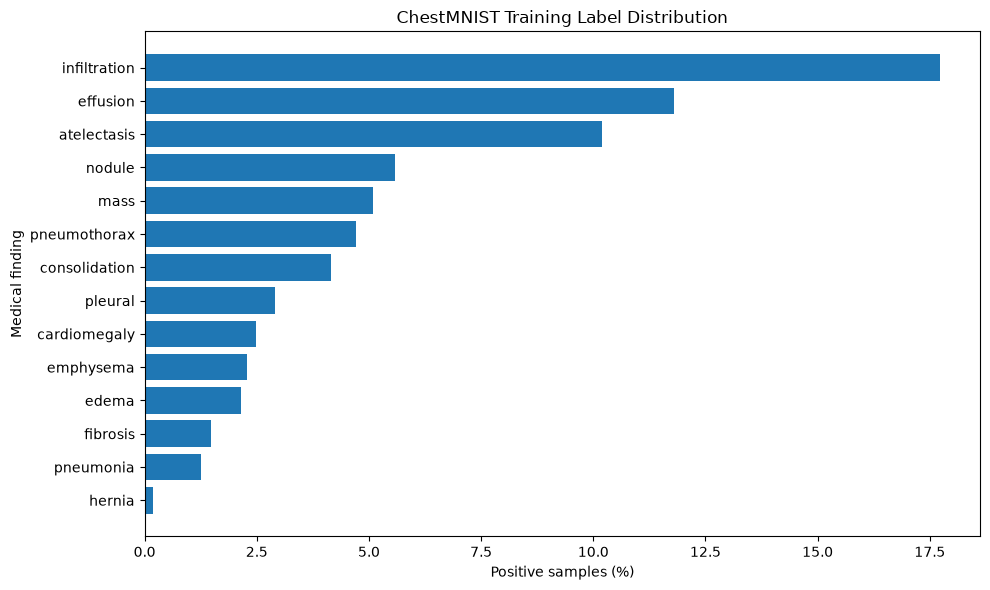

In [10]:
import matplotlib.pyplot as plt

plot_data = label_distribution.sort_values(
    by="positive_percent",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_data["class_name"],
    plot_data["positive_percent"]
)

plt.xlabel("Positive samples (%)")
plt.ylabel("Medical finding")
plt.title("ChestMNIST Training Label Distribution")

plt.tight_layout()
plt.show()

In [11]:
findings_per_image = train_labels.sum(axis=1)

finding_counts, image_counts = np.unique(
    findings_per_image,
    return_counts=True
)

findings_distribution = pd.DataFrame({
    "positive_findings_per_image": finding_counts,
    "image_count": image_counts,
    "image_percent": image_counts / len(train_labels) * 100
})

findings_distribution

,positive_findings_per_image,image_count,image_percent
0,0,42405,54.041138
1,1,21602,27.529694
2,2,9970,12.705816
3,3,3378,4.304940
4,4,829,1.056482
5,5,218,0.277820
6,6,49,0.062446
7,7,14,0.017842
8,8,1,0.001274
9,9,2,0.002549


In [12]:
def read_first_samples(archive, filename, sample_count):
    with archive.open(filename) as file:
        version = np.lib.format.read_magic(file)

        if version == (1, 0):
            shape, _, dtype = np.lib.format.read_array_header_1_0(file)
        else:
            shape, _, dtype = np.lib.format.read_array_header_2_0(file)

        sample_shape = shape[1:]
        value_count = sample_count * int(np.prod(sample_shape))

        raw_data = file.read(value_count * dtype.itemsize)

        return np.frombuffer(
            raw_data,
            dtype=dtype,
            count=value_count
        ).reshape(sample_count, *sample_shape)


sample_count = 6

with zipfile.ZipFile(dataset_path, "r") as archive:
    sample_images = read_first_samples(
        archive,
        "train_images.npy",
        sample_count
    )

    sample_labels = read_first_samples(
        archive,
        "train_labels.npy",
        sample_count
    )

print("Images shape:", sample_images.shape)
print("Labels shape:", sample_labels.shape)

Images shape: (6, 224, 224)
Labels shape: (6, 14)


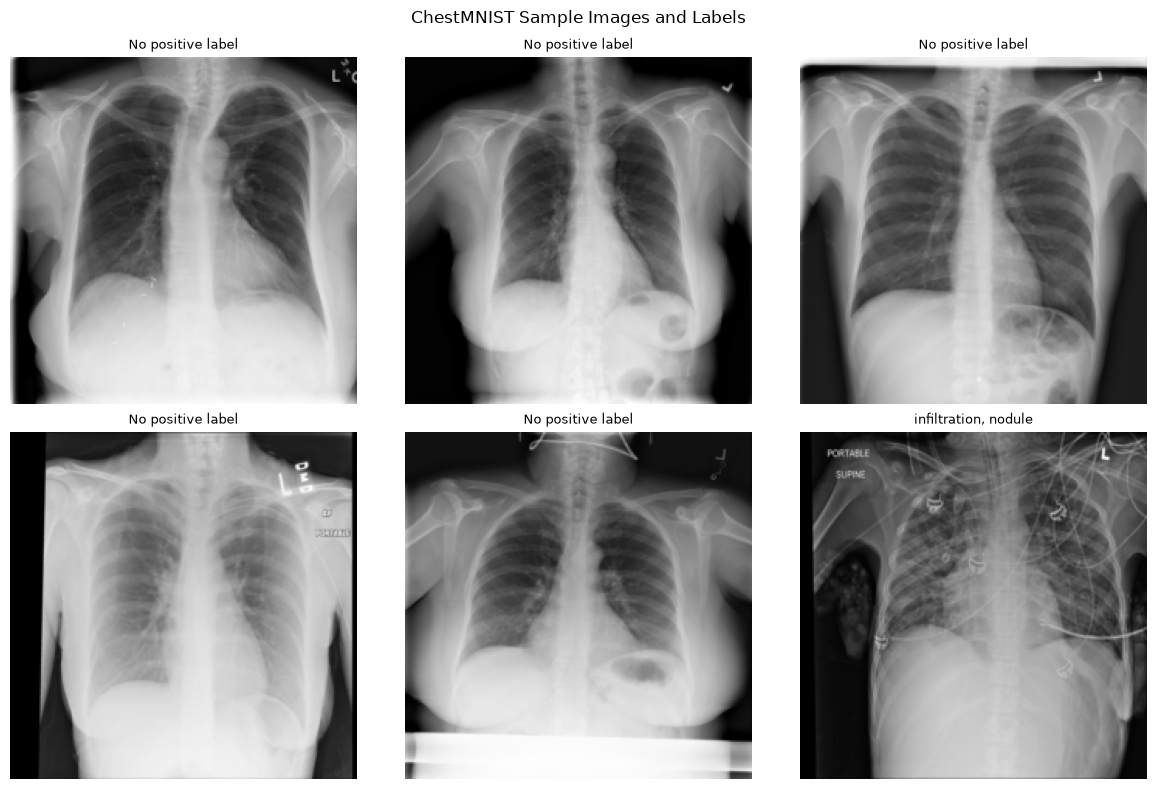

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for index, axis in enumerate(axes.flat):
    positive_indices = np.where(sample_labels[index] == 1)[0]

    positive_names = [
        class_names[class_index]
        for class_index in positive_indices
    ]

    title = (
        ", ".join(positive_names)
        if positive_names
        else "No positive label"
    )

    axis.imshow(sample_images[index], cmap="gray")
    axis.set_title(title, fontsize=9)
    axis.axis("off")

plt.suptitle("ChestMNIST Sample Images and Labels")
plt.tight_layout()
plt.show()

In [15]:
selected_classes = [
    "infiltration",
    "effusion",
    "atelectasis",
    "nodule",
    "mass",
    "pneumothorax",
]

selected_indices = {}

for class_name in selected_classes:
    class_index = class_names.index(class_name)
    positive_indices = np.where(train_labels[:, class_index] == 1)[0]
    selected_indices[class_name] = int(positive_indices[0])

print(selected_indices)

{'infiltration': 5, 'effusion': 8, 'atelectasis': 24, 'nodule': 5, 'mass': 62, 'pneumothorax': 6}


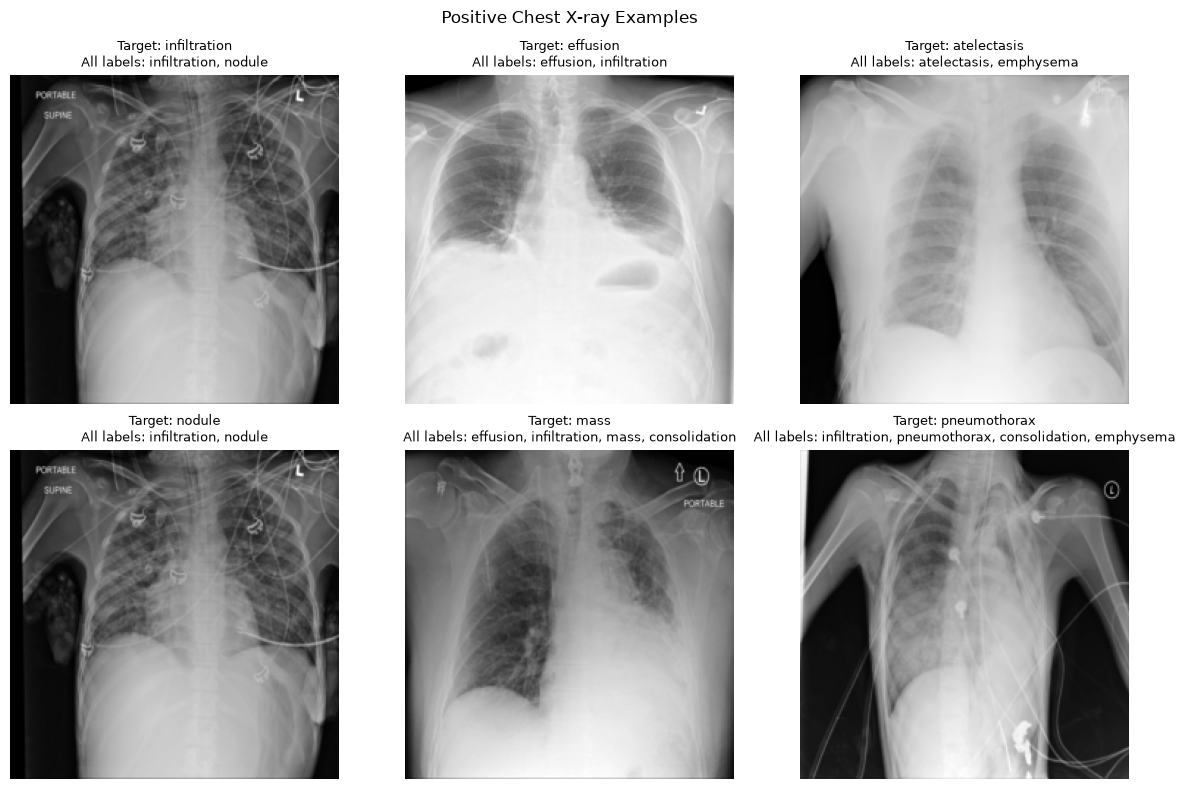

In [17]:
max_index = max(selected_indices.values())

with zipfile.ZipFile(dataset_path, "r") as archive:
    positive_images = read_first_samples(
        archive,
        "train_images.npy",
        max_index + 1
    )

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for axis, class_name in zip(axes.flat, selected_classes):
    image_index = selected_indices[class_name]
    image = positive_images[image_index]

    all_positive_indices = np.where(train_labels[image_index] == 1)[0]
    all_positive_names = [
        class_names[index]
        for index in all_positive_indices
    ]

    axis.imshow(image, cmap="gray")
    axis.set_title(
        f"Target: {class_name}\n"
        f"All labels: {', '.join(all_positive_names)}",
        fontsize=9
    )
    axis.axis("off")

plt.suptitle("Positive Chest X-ray Examples")
plt.tight_layout()
plt.show()

In [18]:
from pathlib import Path
import numpy as np

PROCESSED_DIR = Path(
    "../data/processed/chestmnist_224"
).resolve()

train_images_mmap = np.load(
    PROCESSED_DIR / "train_images.npy",
    mmap_mode="r"
)

train_labels_mmap = np.load(
    PROCESSED_DIR / "train_labels.npy",
    mmap_mode="r"
)

sample_index = 5
sample_image = train_images_mmap[sample_index]
sample_label = train_labels_mmap[sample_index]

print("Images type:", type(train_images_mmap))
print("Images shape:", train_images_mmap.shape)
print("Labels shape:", train_labels_mmap.shape)
print("Sample image shape:", sample_image.shape)
print("Sample label:", sample_label)
print("Positive labels:", sample_label.sum())

Images type: <class 'numpy.memmap'>
Images shape: (78468, 224, 224)
Labels shape: (78468, 14)
Sample image shape: (224, 224)
Sample label: [0 0 0 1 0 1 0 0 0 0 0 0 0 0]
Positive labels: 2
